# Rodrigo Baruch Rivera Rico
# Curso de Optimización 
# Tarea 2

| Descripción:                         | Fechas                  |
|--------------------------------------|-------------------------|
| Fecha de publicación del documento:  | **Agosto  29, 2026**    |
| Fecha límite de entrega de la tarea: | **Septiembre 6, 2026**  |

## Indicaciones


Este notebook debe ser un reporte de la tarea, por lo cual:

- Para los ejercicios teóricos puede escribir la respuesta en una celda Markdown o
  insertar una imagen con la respuesta si se ve claran las palabras.
- Para los ejercicios prácticos hay que escribir el código de las funciones que implementan
  los algoritmos y los casos de prueba en C o C++. Ejecute las celdas para que queden registrados
  los resultados.
- Cuando se dice que una función de C tiene que devolver una serie de valores,
  puede definir algunos de los argumentos de la función como apuntadores o indicar que
  se pasan los valores de una variable por referencia, para que puedan ser modificados
  dentro de la función. También podría definir una estructura de datos, pero tome en cuenta
  que para cada algoritmo tendría que definir una estructura de datos diferente. La elección
  de como define las entradas y salidas de una función es libre.
- En caso que se pida generar una gráfica, puede exportar los datos que se necesitan a
  un archivo CSV, Excel o Json, y en usar otro Notebook para leer los datos y generar la gráfica
  usando Julia, Python o R.
- Hay que subir al Classroom el notebook y los archivos necesarios para ejecutar las funciones.
- También hay que exportar el notebook a PDF y agregarlo al Classroom para poner anotaciones
  y dar la retroalimentación correspondiente de la tarea.

----

In [175]:
from pathlib import Path

for archivo in Path(".").rglob("*.[ch]"):
    print(archivo)

Ejercicio4.c
Ejercicio5.c
epsilon\epsilon.c
epsilon\epsilon.h
funciones\funciones_prueba.c
funciones\funciones_prueba.h
optimizacion\optimizacion.c
optimizacion\optimizacion.h


In [ ]:
# %load epsilon/epsilon.c
#include <stdio.h>
#include "epsilon.h"

double epsilon(void){
    
    double eps = 0.5;
    double unit = 1.0;
    double val = unit + eps;

    while(val > unit){
        eps/=2;
        val = unit + eps;
    }
    eps = 2*eps;

    return eps;
}

In [ ]:
# %load funciones/funciones_prueba.c

#include <math.h>
#include "funciones_prueba.h"

double f1(double x){
    return 0.2*x*log(x) + (x - 2.3)*(x - 2.3);
}

double df1(double x){
    return 2.0*x + 0.2 * log(x) - 4.4;
}

double ddf1(double x){
    return 0.2/x + 2.0;
}

double f2(double x){
    return -(1.5 - 3.0*x)*sin(18.0*x);
}

double df2(double x){
    return 3*sin(18.0*x) + (54.0*x - 27.0)*cos(18.0*x);
}

double ddf2(double x){
    return (486.0 - 972.0*x)*sin(18.0*x) + 108.0*cos(18.0*x);
}

double f3(double x){
    return 0.5*(x-1)*(x-1) + 3*sin(x);
}

double df3(double x){
    return x + 3.0*cos(x) - 1.0;
}

double ddf3(double x){
    return 1.0 - 3.0*sin(x);
}

double f4(double x){
    return x + 2*fabs(sin(x));
}

In [ ]:
# %load optimizacion/optimizacion.c
#include <math.h>
#include "optimizacion.h"

int dorada(double *resultados, double (*f)(double), double l, double u, double tol, int N){

    double x_k, x_1, x_3, b;
    double x_l = l, x_u = u;
    double rho = (sqrt(5.0)-1.0)/2.0;
    int res;
    
    for(int k=1;k<=N;k++){
        if(x_u - x_l < tol){
            x_k = f(x_l) < f(x_u) ? x_l : x_u;
            res = 0; // Se cumple tol
            
            resultados[0] = x_k;
            resultados[1] = x_l;
            resultados[2] = x_u;
            resultados[3] = k-1;
            resultados[4] = res;

            return res;
        }

        b = rho*(x_u - x_l);
        x_1 = x_u - b;
        x_3 = x_l + b;

        if(f(x_1) < f(x_3)){
            x_u = x_3;
            x_k = x_1;
        }
        else{
            x_l = x_1;
            x_k = x_3;
        }
    }
    res = 1;    // No se cumple tol

    resultados[0] = x_k;
    resultados[1] = x_l;
    resultados[2] = x_u;
    resultados[3] = N;
    resultados[4] = res;

    return res;
}

int newton(double *resultados, double (*df)(double), double (*ddf)(double), double x, double tol, int N){

    double x_k = x;
    double raiz;
    double df_k = df(x_k);
    double ddf_k;

    int res;

    for(int k=1;k<=N;k++){

        // Si hay divergencia
        if(isnan(x_k)){
            res = 1;    // No se cumple tol

            resultados[0] = x_k;
            resultados[1] = df_k;
            resultados[2] = k-1;
            resultados[3] = res;

            return res;
        }

        if(fabs(df_k) < tol){
            raiz = x_k;
            res = 0;    // Se cumple tol

            resultados[0] = raiz;
            resultados[1] = df_k;
            resultados[2] = k-1;
            resultados[3] = res;

            return res;
        }

        ddf_k = ddf(x_k);
        x_k = x_k - df_k/ddf_k;
        df_k = df(x_k);
    }
    res = 1; // No se cumple tol

    resultados[0] = x_k;
    resultados[1] = df_k;
    resultados[2] = N;
    resultados[3] = res;

    return res;
}


----

## ✔ Ejercicio 1 (1.2 puntos)

Sean $a_1, a_2, ..., a_n \in \mathbb{R}$. Considere la función $f:\mathbb{R} \rightarrow \mathbb{R}$
definida como

$$f(x) = \sqrt{(x - a_1)^2 + (x - a_2)^2 + ... + (x - a_n)^2}.$$

Encuentre el mínimo global de la función $f$. Justifique su respuesta.

### Solución:

Sea $f(x)=\sqrt{\sum (x-a_i)^2}$. Dejaremos implícito el índice de la suma, el cual corre desde $i=1$ hasta $i=n$. Lo anterior con la finalidad de ahorrar notación.

Hagamos $y=f(x)$, entonces $y^2=\sum (x-a_i)^2$.

Derivando implícitamente: 
$$ y\,\frac{dy}{dx}=\sum (x-a_i)=nx-\sum a_i.$$

Por lo tanto, $$f'(x)=\frac{dy}{dx}=\frac{nx-\sum a_i}{\sqrt{\sum (x-a_i)^2}}.$$

El punto crítico es tal que $f'(x)=0$, lo cual es cierto si y solo si el numerado es igual a $0$, es decir cuando $x=\frac{\sum a_i}{n}$.

Ahora, calculemos la segunda derivada. Como $y\frac{dy}{dx}=nx-\sum a_i$, entonces al derivar implícitamente tenemos que:
$$\left(\frac{dy}{dx}\right)^2+y\,\frac{d^2y}{dx^2}=n.$$

De modo que, $$f''(x)=\frac{d^2y}{dx^2}=\frac{n-\left(\frac{dy}{dx}\right)^2}{y}=\frac{n-\left(\frac{nx-\sum a_i}{\sqrt{\sum (x-a_i)^2}}\right)^2}{\sqrt{\sum (x-a_i)^2}}.$$

Haciendo álgebra tenemos que:
\begin{align*}
    f''(x)&=\frac{n\,\sum(x-a_i)^2-(nx)^2+2nx\sum a_i-(\sum a_i)^2}{\sum(x-a_i)^2}\cdot \frac{1}{\sqrt{\sum(x-a_i)^2}} \\
    &= \frac{n\left(nx^2-2x\sum a_i+\sum a_i^2\right)-(nx)^2+2nx\sum a_i-(\sum a_i)^2}{\sum(x-a_i)^2}\cdot \frac{1}{\sqrt{\sum(x-a_i)^2}} \\
    & = \frac{n\sum a_i^2-(\sum a_i)^2}{[\sum(x-a_i)^2]^{3/2}}.
\end{align*}

Para el caso en que no todas las $a_i$ son iguales, notamos que el denominador es una cantidad positiva. Veamos que el numerador también es una cantidad positiva, para ello recordemos el _Teorema de Cauchy-Schwarz_:

$$\text{Sean }a_1,\dots,a_n \text{ y } b_1,\dots,b_n \text{ números reales cualesquiera.}\\
\left(\sum a_i\,b_i\right)^2 \leq \left(\sum a_i^2\right)\left(\sum b_i^2\right).
$$

En particular, para nuestro caso $b_i=1$ para cada $i$. De modo que,
\begin{align*}
\left(\sum a_i\right)^2 &\leq n\,\sum a_i^2 \\
0 &\leq n\,\sum a_i^2 - \left(\sum a_i\right)^2 .
\end{align*}

Y en el caso en que no todas las $a_i$ son iguales: $0 < n\,\sum a_i^2 - \left(\sum a_i\right)^2$.

Por lo tanto, $f''(x)>0$ para toda $x$, en particular para el punto crítico $x=\frac{\sum a_i}{n}$.

Ahora tomemos el caso en que todas las $a_i$ son iguales; hagamos $a=a_i$. En este caso $f(x)=\sqrt{n(x-a)^2}=\sqrt{n}|x-a|$.

Notemos que $f(x)$ es la función _valor absoluto_ desplazada $a$ unidades en el eje horizontal, y multiplicada por un factor $\sqrt{n}$. Ya sabemos que esta función tiene un mínimo global en $x=a$.

Concluímos que $x=\frac{\sum a_i}{n}$ es mínimo global. Observemos que para el caso en que todas las $a_i$ sean iguales a un real $a$, $x=\frac{\sum a_i}{n}=\frac{n\,a}{n}=a$.

```



```
----

## ✔ Ejercicio 2 (1.6 puntos)

Se quiere construir una 
caja rectangular cerrada con base cuadrada  tiene un área superficial de $S$ $cm^2$. 
Determine la longitud $x$ de un lado de la base de modo que el volumen que puede contener la caja sea máximo.

### Solución:



La caja en cuestión tiene un volumen dado por $V(x,h)=h\cdot x^2$, donde $h$ es la altura y $x$ es la longitud de uno de los lados de la base cuadrada.

El área superficial es $A(x)=2x^2+4x\cdot h=S$, donde el primer término es el área superficial de ambas tapas cuadradas y el segundo término corresponde a las cuatro tapas laterales.

Entonces, $h=\frac{S-2x^2}{4x}$. Sustituimos en la ecuación del volumen para obtener: $V(x)=\frac{S-2x^2}{4x}\cdot x^2=\frac{1}{4}(x\cdot S-2x^3)$.

Queremos maximizar el volumen, por lo tanto hay que encontrar el máximo de $V(x)$.

Calculamos la derivada:
$$V'(x)=\frac{1}{4}(S-6x^2)$$

Puntos críticos cuando $V(x)=0$. Esto ocurre cuando $S-6x^2=0$ si y solo si $x=\pm\sqrt{\frac{S}{6}}$.

Dado que nos interesan longitudes positivas, tomamos la solución positiva: $x=\sqrt{\frac{S}{6}}$.

Verificamos que dicho punto crítico sea máximo con el criterio de la segunda derivada:
$$V''(x)=-3x.$$

Notamos que $V''(x)<0$ para cada $x>0$, en particular para $x=\sqrt{\frac{S}{6}}$.

Por lo tanto, la longitud $x$ tal que hace que el volumen sea máximo es $x=\sqrt{\frac{S}{6}}\;cm$.




```



```
----

## ✔ Ejercicio 3 (1.2 puntos)

Considere el problema de minimizar el función $f(x) = x^{\frac{4}{3}}$. Note que
$x_*=0$ es el minimizador global de $f$.

- Escriba la expresión para generar la secuencia $\{x_k\}$ de puntos cuando se aplica el método de Newton. 
- Muestre que sin importar que tan cerca esté el punto inicial $x_0$ de $0$, la secuencia de puntos no converge a $0$.

### Solución:

El método de Newton es: $$x_{k+1}=x_k-\frac{f'(x_k)}{f''(x_k)}.$$

Tenemos que:
\begin{align*}
f(x) &= x^{4/3}. \\
f'(x) &= \frac{4}{3}x^{1/3}. \\
f''(x) &= \frac{4}{9} x^{-2/3}.
\end{align*}

Luego, 
$$x_{k+1}=x_k-\frac{f'(x_k)}{f''(x_k)}=-2x_k.$$

Entonces, la secuencia de puntos $\{x_k\}$ del método de Newton se puede escribir como $x_k=(-1)^k\,2^k\,x_0$ con $k\geq0$.

Luego, $\lim_{k\to\infty}x_k$ diverge sin importar el valor que tome el punto inicial $x_0$.

```



```
----

## ✔ Ejercicio 4 (3 puntos)

Programar y probar el método de la sección dorada descrito en el Algoritmo 2 de la Clase 5 
para calcular el mínimo de una función en un intervalo.

1. Programar la función que implementa el método de la sección dorada recibe como argumentos. 
   La función debe devolver:
   
- el último punto $x_k$ generado,
- los extremos del último intervalo de búsqueda $[x_l, x_u]$,
- el número de iteraciones $k$ realizadas y
- la variable booleana $res$ que indica si el algoritmo terminó porque se cumplió el criterio de paso o no.
   
2. Probar el método con las siguientes funciones:

$$f_1(x) = 0.2 x \ln x + (x - 2.3)^2, \qquad x_l = 0.5, x_u = 4.$$

$$f_2(x) = -(1.5 - 3.0 x)\sin(18 x), \qquad x_l = 0.0, x_u = 1.4.$$

$$f_3(x) = 0.5(x-1)^2 + 3\sin x, \qquad x_l = -4, x_u = 6.$$

$$f_4(x) = x + 2|\sin x|, \qquad x_l = -4, x_u = 6.$$
 
- Use el intervalo que se especifica en cada caso y $N=50$.
- Use como tolerancia $\tau = \epsilon_m^{1/3}$, donde $\epsilon_m$ es el épsilon de la máquina.
- Imprima los valores $k, x_k, f_k, x_u-x_l$ y $res$.
- En python, genere la gráfica de la función en el intervalo $[x_l, x_u]$ y
  marque el punto $(x_k, f_k)$.

### Solución:

In [ ]:
# %load Ejercicio4.c
#include <stdio.h>
#include <math.h>
#include <stdlib.h>
#include "optimizacion/optimizacion.h"
#include "funciones/funciones_prueba.h"
#include "epsilon/epsilon.h"

#define OK 0
#define ERROR_MEM 1 

int initMemory(double **, int);

int main(void){

    double *resultado = NULL;
    int n = 5;

    FILE *pw = fopen("dorada.bin", "wb");
    if(!pw){
        printf("\nError al crear el archivo");
        return 1;
    }

    if(initMemory(&resultado,n) == ERROR_MEM){
        printf("\nNo se pudo asignar memoria.");
        return 1;
    }

    printf("\n*** Seccion dorada ***\n");
    dorada(resultado, f1, 0.5, 4.0, pow(epsilon(),1.0/3.0), 50);
    printf("\nf(x)        = 0.2xln(x) + (x - 2.3)^2");
    printf("\nk           = %d", (int)resultado[3]);
    printf("\nx_k         = %.10e", resultado[0]);
    printf("\nf_k         = %.10e", f1(resultado[0]));
    printf("\nx_u - x_l   = %.10e", resultado[2]-resultado[1]);
    printf("\nres         = %d\n", (int)resultado[4]);
    fwrite(resultado, sizeof(double), n, pw);

    dorada(resultado, f2, 0.0, 1.4, pow(epsilon(),1.0/3.0), 50);
    printf("\nf(x)        = -(1.5 - 3.0 x) sin(18 x)");
    printf("\nk           = %d", (int)resultado[3]);
    printf("\nx_k         = %.10e", resultado[0]);
    printf("\nf_k         = %.10e", f2(resultado[0]));
    printf("\nx_u - x_l   = %.10e", resultado[2]-resultado[1]);
    printf("\nres         = %d\n", (int)resultado[4]);
    fwrite(resultado, sizeof(double), n, pw);

    dorada(resultado, f3, -4.0, 6.0, pow(epsilon(),1.0/3.0), 50);
    printf("\nf(x)        = 0.5(x-1)^2 + 3 sin(x)");
    printf("\nk           = %d", (int)resultado[3]);
    printf("\nx_k         = %.10e", resultado[0]);
    printf("\nf_k         = %.10e", f3(resultado[0]));
    printf("\nx_u - x_l   = %.10e", resultado[2]-resultado[1]);
    printf("\nres         = %d\n", (int)resultado[4]);
    fwrite(resultado, sizeof(double), n, pw);

    dorada(resultado, f4, -4.0, 6, pow(epsilon(),1.0/3.0), 50);
    printf("\nf(x)        = x + 2|sin x|");
    printf("\nk           = %d", (int)resultado[3]);
    printf("\nx_k         = %.10e", resultado[0]);
    printf("\nf_k         = %.10e", f4(resultado[0]));
    printf("\nx_u - x_l   = %.10e", resultado[2]-resultado[1]);
    printf("\nres         = %d\n", (int)resultado[4]);
    fwrite(resultado, sizeof(double), n, pw);
    
    fclose(pw);

    free(resultado);

    return 0;
}

int initMemory(double **pv, int n){

    *pv = malloc(n*sizeof(double));

    if(!pv){
        return ERROR_MEM;
    }

    return OK;
}

In [181]:
!gcc Ejercicio4.c optimizacion\optimizacion.c funciones\funciones_prueba.c epsilon\epsilon.c -o Ejercicio4.exe & Ejercicio4.exe


*** Seccion dorada ***

f(x)        = 0.2xln(x) + (x - 2.3)^2
k           = 28
x_k         = 2.1246373169e+00
f_k         = 3.5097788015e-01
x_u - x_l   = 4.9250893901e-06
res         = 0

f(x)        = -(1.5 - 3.0 x) sin(18 x)
k           = 26
x_k         = 6.3286900450e-01
f_k         = -3.6774890839e-01
x_u - x_l   = 5.1576205686e-06
res         = 0

f(x)        = 0.5(x-1)^2 + 3 sin(x)
k           = 30
x_k         = -8.8946852620e-01
f_k         = -5.4516570963e-01
x_u - x_l   = 5.3749049985e-06
res         = 0

f(x)        = x + 2|sin x|
k           = 30
x_k         = -3.2249429989e-06
f_k         = 3.2249429989e-06
x_u - x_l   = 5.3749049986e-06
res         = 0


In [116]:
import matplotlib.pyplot as plt
import numpy as np

# Enable LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # Optional: Matches standard LaTeX font style
})

In [22]:
def f1(x):
    return 0.2*x*np.log(x) + (x - 2.3)*(x - 2.3)

def f2(x):
    return -(1.5 - 3.0*x)*np.sin(18.0*x)

def f3(x):
    return 0.5*(x-1)*(x-1) + 3*np.sin(x)

def f4(x):
    return x + 2*abs(np.sin(x));

In [158]:
# Leer los bytes crudos especificando el tipo de dato (double en C = float64 en NumPy)
datos = np.fromfile('dorada.bin', dtype=np.float64)

# datos

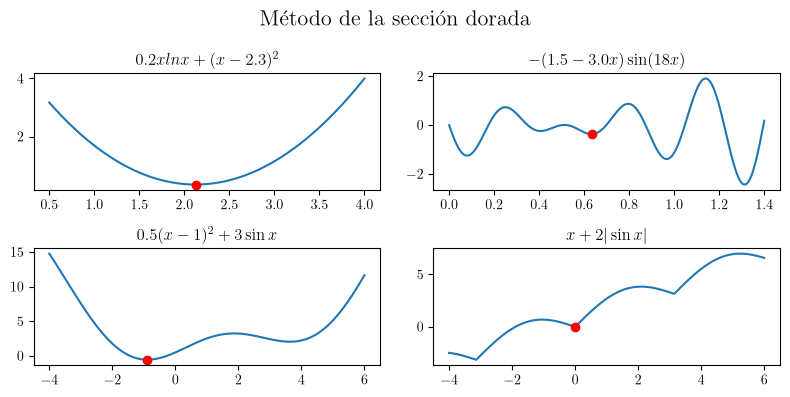

In [160]:
fig, axs = plt.subplots(2, 2, figsize=(8, 4))

# Para f1
x = np.linspace(0.5,4,500)
x_k = datos[0]
f_k = f1(datos[0])
axs[0,0].plot(x, f1(x))
axs[0,0].plot(x_k,f_k,'o',color='red')
axs[0,0].set_title(r'$0.2 x ln x + (x - 2.3)^2$')


# Para f2
x = np.linspace(0,1.4,500)
x_k = datos[5]
f_k = f2(datos[5])
axs[0,1].plot(x, f2(x))
axs[0,1].plot(x_k,f_k,'o',color='red')
axs[0,1].set_title(r'$-(1.5 - 3.0 x) \sin(18 x)$')

# Para f3
x = np.linspace(-4,6,500)
x_k = datos[10]
f_k = f3(datos[10])
axs[1,0].plot(x, f3(x))
axs[1,0].plot(x_k,f_k,'o', color='red')
axs[1,0].set_title(r'$0.5(x-1)^2 + 3\sin x$')

#Para f4
x = np.linspace(-4,6,500)
x_k = datos[15]
f_k = f4(datos[15])
axs[1,1].plot(x, f4(x))
axs[1,1].plot(x_k,f_k,'o', color='red')
axs[1,1].set_title(r'$x + 2|\sin x|$')

plt.suptitle("Método de la sección dorada",fontsize=16)
plt.tight_layout()
plt.show()

```



```
----

## ✔ Ejercicio 5 (3 puntos)

Programar y probar el método de Newton para calcular puntos estacionarios de funciones de una variable.

1. Escriba la función que corresponde al Algoritmo 1 de la clase 5.
   La función debe devolver:
   
- el último punto $x_k$ generado,
- el valor $f'(x_k)$,
- el número de iteraciones $k$ realizadas y
- la variable booleana $res$ que indica si el algoritmo terminó porque se cumplió el criterio de paso o no.

2. Escriba las funciones que corresponden a las primeras y segundas derivadas de las funciones $f_1$, $f_2$ y $f_3$
   del ejercicio anterior.
   
4. Pruebe el algoritmo del método de Newton usando las funciones $f_1$, $f_2$ y $f_3$:
   
- Use $N=50$ y  tolerancia $\tau = \epsilon_m^{2/3}$, donde $\epsilon_m$ es el épsilon de la máquina.
- Use como punto inicial $x_0 = x_u$, donde $x_u$ es el extremo del intervalo inicial indicado en el ejercicio anterior.
- En cada caso imprima los valores $k, x_k, f(x_k), f'(x_k)$ y $res$.
- En python, genere la gráfica de la función y muestre el punto $(x_k, f(x_k))$.


### Solución:

In [ ]:
# %load Ejercicio5.c
#include <stdio.h>
#include <math.h>
#include <stdlib.h>
#include "optimizacion/optimizacion.h"
#include "funciones/funciones_prueba.h"
#include "epsilon/epsilon.h"

#define OK 0
#define ERROR_MEM 1 

int initMemory(double **, int);

int main(void){

    double *resultado = NULL;
    int n = 4;

    FILE *pw = fopen("newton.bin", "wb");
    if(!pw){
        printf("\nError al crear el archivo");
        return 1;
    }

    if(initMemory(&resultado,n) == ERROR_MEM){
        printf("\nNo se pudo asignar memoria.");
        return 1;
    }
    
    printf("\n*** Newton ***\n");
    newton(resultado,df1,ddf1,4.0,pow(epsilon(),2.0/3.0),50);
    printf("\nf(x)        = 0.2xln(x) + (x - 2.3)^2");
    printf("\nk           = %d", (int)resultado[2]);
    printf("\nx_k         = %.10e", resultado[0]);
    printf("\nf_k         = %.10e", f1(resultado[0]));
    printf("\ndf_k        = %.10e", df1(resultado[0]));
    printf("\nres         = %d\n", (int)resultado[3]);
    fwrite(resultado, sizeof(double), n, pw);

    newton(resultado,df2,ddf2,1.4,pow(epsilon(),2.0/3.0),50);
    printf("\nf(x)        = -(1.5 - 3.0 x) sin(18 x)");
    printf("\nk           = %d", (int)resultado[2]);
    printf("\nx_k         = %.10e", resultado[0]);
    printf("\nf_k         = %.10e", f2(resultado[0]));
    printf("\ndf_k        = %.10e", df2(resultado[0]));
    printf("\nres         = %d\n", (int)resultado[3]);
    fwrite(resultado, sizeof(double), n, pw);

    newton(resultado,df3,ddf3,6.0,pow(epsilon(),2.0/3.0),50);
    printf("\nf(x)        = 0.5(x-1)^2 + 3 sin(x)");
    printf("\nk           = %d", (int)resultado[2]);
    printf("\nx_k         = %.10e", resultado[0]);
    printf("\nf_k         = %.10e", f3(resultado[0]));
    printf("\ndf_k        = %.10e", df3(resultado[0]));
    printf("\nres         = %d\n", (int)resultado[3]);
    fwrite(resultado, sizeof(double), n, pw);

    fclose(pw);
    
    free(resultado);

    return 0;
}

int initMemory(double **pv, int n){

    *pv = malloc(n*sizeof(double));

    if(!pv){
        return ERROR_MEM;
    }

    return OK;
}

In [182]:
!gcc Ejercicio5.c optimizacion\optimizacion.c funciones\funciones_prueba.c epsilon\epsilon.c -o Ejercicio5.exe & Ejercicio5.exe


*** Newton ***

f(x)        = 0.2xln(x) + (x - 2.3)^2
k           = 3
x_k         = 2.1246397731e+00
f_k         = 3.5097788014e-01
df_k        = -1.6520118606e-13
res         = 0

f(x)        = -(1.5 - 3.0 x) sin(18 x)
k           = 4
x_k         = 4.0653765537e-01
f_k         = -2.4102157712e-01
df_k        = -8.8817841970e-16
res         = 0

f(x)        = 0.5(x-1)^2 + 3 sin(x)
k           = 4
x_k         = 1.8623649293e+00
f_k         = 3.2452190899e+00
df_k        = 2.4702462298e-12
res         = 0


In [171]:
datos = np.fromfile('newton.bin', dtype=np.float64)

# datos

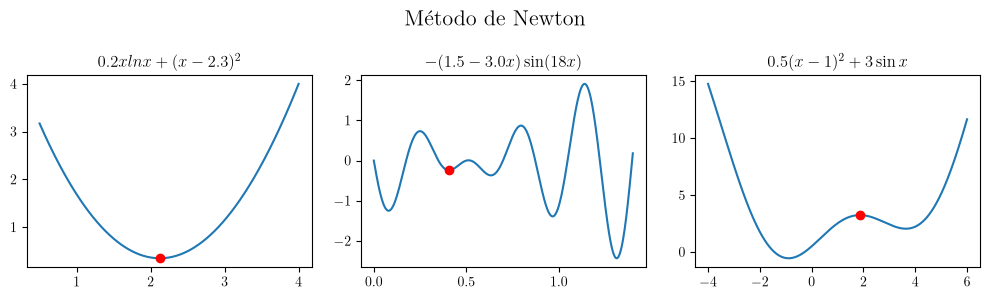

In [172]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

# Para f1
x = np.linspace(0.5,4,500)
x_k = datos[0]
f_k = f1(datos[0])
axs[0].plot(x, f1(x))
axs[0].plot(x_k,f_k,'o',color='red')
axs[0].set_title(r'$0.2 x ln x + (x - 2.3)^2$')


# Para f2
x = np.linspace(0,1.4,500)
x_k = datos[4]
f_k = f2(datos[4])
axs[1].plot(x, f2(x))
axs[1].plot(x_k,f_k,'o',color='red')
axs[1].set_title(r'$-(1.5 - 3.0 x) \sin(18 x)$')

# Para f3
x = np.linspace(-4,6,500)
x_k = datos[8]
f_k = f3(datos[8])
axs[2].plot(x, f3(x))
axs[2].plot(x_k,f_k,'o', color='red')
axs[2].set_title(r'$0.5(x-1)^2 + 3\sin x$')

plt.suptitle("Método de Newton",fontsize=16)
plt.tight_layout()
plt.show()

```



```
----